# Installs

In [1]:
# !pip install shap
# !pip install grad-cam
# !pip install tqdm
# !pip install ultralytics opencv-python nibabel kagglehub
# !pip install ultralytics nibabel opencv-python matplotlib numpy pandas pillow scikit-learn

# Imports

In [2]:
import numpy as np
print(np.__version__)
import os
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import kagglehub
import nibabel as nib
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from ultralytics import YOLO

2.2.6


c:\Users\conno\anaconda3\envs\brats_final\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# Dataset - Brats 2020

In [3]:
import kagglehub

path = kagglehub.dataset_download(
    "awsaf49/brats20-dataset-training-validation"
)

print("Dataset path:", path)

Dataset path: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1


In [4]:
os.listdir(path)

['BraTS2020_TrainingData', 'BraTS2020_ValidationData']

In [5]:
base_path = os.path.join(
    path,
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

cases = []

for folder in os.listdir(base_path):

    full_path = os.path.join(base_path, folder)

    if os.path.isdir(full_path):
        cases.append(full_path)

print("Total cases:", len(cases))
print(cases[:3])

Total cases: 369
['C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_001', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_002', 'C:\\Users\\conno\\.cache\\kagglehub\\datasets\\awsaf49\\brats20-dataset-training-validation\\versions\\1\\BraTS2020_TrainingData\\MICCAI_BraTS2020_TrainingData\\BraTS20_Training_003']


In [6]:
# Loads one MRI scan

sample_case = cases[0]

files = os.listdir(sample_case)
print(files)

['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']


In [7]:
# Loading MRI and Mask

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(sample_case, file)

    if "seg" in file.lower():
        mask_path = os.path.join(sample_case, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

FLAIR: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_flair.nii
MASK: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001\BraTS20_Training_001_seg.nii


In [8]:
# getting structure of data

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

    # stoppinh after a few folders
    if "BraTS20_Training_001" in root:
        break

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
-------

In [9]:
# getting structure of data

print(path)

for root, dirs, files in os.walk(path):
    print(root)
    print(files[:5])
    print("-" * 50)

    # stoppinh after a few folders
    if "BraTS20_Training_001" in root:
        break

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
[]
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData
['name_mapping.csv', 'survival_info.csv']
--------------------------------------------------
C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_001
['BraTS20_Training_001_flair.nii', 'BraTS20_Training_001_seg.nii', 'BraTS20_Training_001_t1.nii', 'BraTS20_Training_001_t1ce.nii', 'BraTS20_Training_001_t2.nii']
-------

In [10]:
# CELL 9 FIND MRI + MASK FILES

patient_folder = None

for folder in os.listdir(path):
    full_path = os.path.join(path, folder)

    if os.path.isdir(full_path):
        patient_folder = full_path
        break

print("Patient folder:", patient_folder)

files = os.listdir(patient_folder)

flair_path = None
mask_path = None

for file in files:

    if "flair" in file.lower():
        flair_path = os.path.join(patient_folder, file)

    if "seg" in file.lower():
        mask_path = os.path.join(patient_folder, file)

print("FLAIR:", flair_path)
print("MASK:", mask_path)

Patient folder: C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
FLAIR: None
MASK: None


In [11]:
base_path = os.path.join(path, "BraTS2020_TrainingData")
print(base_path)
print(os.listdir(base_path)[:5])

C:\Users\conno\.cache\kagglehub\datasets\awsaf49\brats20-dataset-training-validation\versions\1\BraTS2020_TrainingData
['MICCAI_BraTS2020_TrainingData']


In [12]:
# Getting MRI shape and Mask shape

base_path = os.path.join(path, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

patient_folder = next(
    os.path.join(base_path, f)
    for f in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, f))
)

files = os.listdir(patient_folder)

flair_path = next(os.path.join(patient_folder, f) for f in files if "flair" in f.lower())
mask_path  = next(os.path.join(patient_folder, f) for f in files if "seg" in f.lower())

flair = nib.load(flair_path).get_fdata()
mask = nib.load(mask_path).get_fdata()

print("MRI shape:", flair.shape)
print("Mask shape:", mask.shape)

MRI shape: (240, 240, 155)
Mask shape: (240, 240, 155)


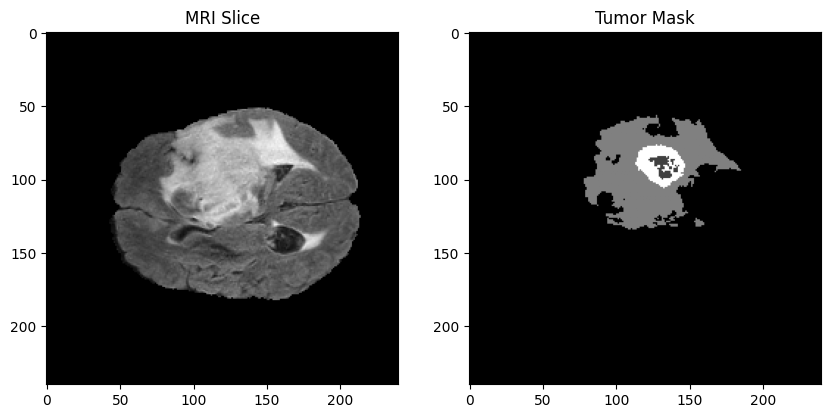

In [13]:
# Show MRI slice and tumor mask
slice_index = 75

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(flair[:,:,slice_index], cmap='gray')
plt.title("MRI Slice")

plt.subplot(1,2,2)
plt.imshow(mask[:,:,slice_index], cmap='gray')
plt.title("Tumor Mask")

plt.show()

In [14]:
# CREATE OUTPUT FOLDERS

BASE_DIR = "brain_tumor_dataset"

folders = [
    "images/train",
    "images/val",
    "labels/train",
    "labels/val"
]

for folder in folders:
    os.makedirs(os.path.join(BASE_DIR, folder), exist_ok=True)

print("Folders created.")

Folders created.


In [15]:
# Convert MASK to POLYGON ( for Yolo v8 segmentation model to work)
import cv2
import numpy as np

def mask_to_polygon(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8) * 255

    kernel = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return None

    largest = max(contours, key=cv2.contourArea)

    if cv2.contourArea(largest) < 20:   # slightly stricter
        return None

    return largest.reshape(-1, 2)

In [16]:
import cv2
import numpy as np

def mask_to_bbox(mask_slice):

    mask = (mask_slice > 0).astype(np.uint8)

    ys, xs = np.where(mask > 0)

    if len(xs) == 0:
        return None

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    return x_min, y_min, x_max, y_max

In [17]:
# ============================================================
# CELL 24 — CREATE YOLO DETECTION LABELS
# ============================================================

image_paths = []
counter = 0

for case in tqdm(cases):

    files = os.listdir(case)

    flair_path = None
    mask_path = None

    for file in files:

        if "flair" in file.lower():
            flair_path = os.path.join(case, file)

        if "seg" in file.lower():
            mask_path = os.path.join(case, file)

    if flair_path is None or mask_path is None:
        continue

    flair = nib.load(flair_path).get_fdata()
    mask = nib.load(mask_path).get_fdata()

    for i in range(35, 115, 8):

        image_slice = flair[:, :, i]
        mask_slice = mask[:, :, i]

        is_tumor = np.max(mask_slice) > 0

        if not is_tumor and np.random.rand() > 0.10:
            continue

        bbox = mask_to_bbox(mask_slice)

        if bbox is None:
            continue

        x_min, y_min, x_max, y_max = bbox

        h, w = image_slice.shape

        x_center = ((x_min + x_max) / 2) / w
        y_center = ((y_min + y_max) / 2) / h

        bbox_width = (x_max - x_min) / w
        bbox_height = (y_max - y_min) / h

        image_slice = cv2.normalize(
            image_slice,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        )

        image_slice = image_slice.astype(np.uint8)

        image_slice = cv2.cvtColor(
            image_slice,
            cv2.COLOR_GRAY2RGB
        )

        filename = f"tumor_{counter}"

        cv2.imwrite(
            f"{BASE_DIR}/images/train/{filename}.jpg",
            image_slice
        )

        with open(
            f"{BASE_DIR}/labels/train/{filename}.txt",
            "w"
        ) as f:

            f.write(
                f"0 {x_center} {y_center} {bbox_width} {bbox_height}"
            )

        image_paths.append(filename)

        counter += 1

print("Total saved images:", counter)

100%|██████████| 369/369 [01:11<00:00,  5.14it/s]

Total saved images: 2594


In [18]:
train_files, val_files = train_test_split(
    image_paths,
    test_size=0.2,
    random_state=42
)

In [19]:
# moving the validation set files
import shutil

for file in val_files:

    shutil.copy(
        f"{BASE_DIR}/images/train/{file}.jpg",
        f"{BASE_DIR}/images/val/{file}.jpg"
    )

    shutil.copy(
        f"{BASE_DIR}/labels/train/{file}.txt",
        f"{BASE_DIR}/labels/val/{file}.txt"
    )

print("Validation files copied.")

Validation files copied.


In [20]:
# creating yolo dataset yaml file
yaml_text = f"""
path: {BASE_DIR}

train: images/train
val: images/val

names:
  0: tumor
"""

In [21]:
model = YOLO("yolov8n.pt")

In [22]:
model.train(
    data="dataset.yaml",
    epochs=10,
    imgsz=192,
    batch=8,
    workers=2,
    mosaic=0,
    fliplr=0.1,
    scale=0.1,
    degrees=0,
    patience=3,
    cache=True
)

New https://pypi.org/project/ultralytics/8.4.62 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.1, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0, multi_scale=0.0, name=train-8, nbs=64, nms=

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000268D0EEC1F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [23]:
# test predictions
results = model.predict(
    source=f"{BASE_DIR}/images/val",
    save=True,
    conf=0.25
)


image 1/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\images\val\tumor_100.jpg: 192x192 1 tumor, 31.1ms
image 2/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\images\val\tumor_1000.jpg: 192x192 1 tumor, 16.4ms
image 3/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\images\val\tumor_1011.jpg: 192x192 1 tumor, 15.8ms
image 4/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\images\val\tumor_1014.jpg: 192x192 1 tumor, 15.8ms
image 5/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\images\val\tumor_1027.jpg: 192x192 1 tumor, 14.0ms
image 6/519 c:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tum

In [24]:
# metric scores
metrics = model.val()

print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.59  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core i7-13700H)
val: Fast image access  (ping: 0.00.0 ms, read: 109.527.6 MB/s, size: 8.9 KB)
val: Scanning C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\brain_tumor_dataset\labels\val.cache... 519 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 519/519  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 33/33 7.8it/s 4.3s0.1s
                   all        519        519      0.907      0.798      0.871      0.624
Speed: 0.1ms preprocess, 5.4ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to C:\Users\conno\Capstone-Repo\New-project-space-that-works\Capstone-Masters-AI\detection_model\runs\detect\val-6
mAP@0.5: 0.8706310774832295
mAP@0.5:0.95: 0.6244175760713823
Precision: 0.9069716541773306
Recall: 0.7976878612716763


In [25]:
# showing the true positive, false positiove or false negative counts
print(metrics.confusion_matrix.matrix)   

[[        432          74]
 [         87           0]]


# Interpretability

In [ ]:
# Looking at YOLO raw output shape for the EigenCAM target
import torch

pytorch_model = model.model
pytorch_model.eval()
sample_name = "tumor_73"
sample_image_path = os.path.join(BASE_DIR, "images", "val", f"{sample_name}.jpg")

original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img_resized = cv2.resize(original_img, (192, 192))
original_float = original_img_resized.astype("float32") / 255.0
img_tensor = torch.from_numpy(original_float).permute(2, 0, 1).unsqueeze(0).float()

device = next(pytorch_model.parameters()).device
img_tensor = img_tensor.to(device)

output = pytorch_model(img_tensor)
print("pytorch_model output type:", type(output))
if isinstance(output, (tuple, list)):
    print("output length:", len(output))
    for i, out in enumerate(output):
        print(i, type(out), getattr(out, "shape", None))
        if torch.is_tensor(out):
            print("  tensor shape:", out.shape)
else:
    print("output shape:", output.shape)

print("model block count:", len(pytorch_model.model))
for idx, layer in enumerate(pytorch_model.model):
    print(idx, layer.__class__.__name__)

pytorch_model output type: <class 'tuple'>
output length: 2
0 <class 'torch.Tensor'> torch.Size([1, 5, 756])
  tensor shape: torch.Size([1, 5, 756])
1 <class 'dict'> None
model block count: 23
0 Conv
1 Conv
2 C2f
3 Conv
4 C2f
5 Conv
6 C2f
7 Conv
8 C2f
9 SPPF
10 Upsample
11 Concat
12 C2f
13 Upsample
14 Concat
15 C2f
16 Conv
17 Concat
18 C2f
19 Conv
20 Concat
21 C2f
22 Detect


# EigenCAM
This placeholder cell is not needed; the actual EigenCAM implementation is in the next cell.

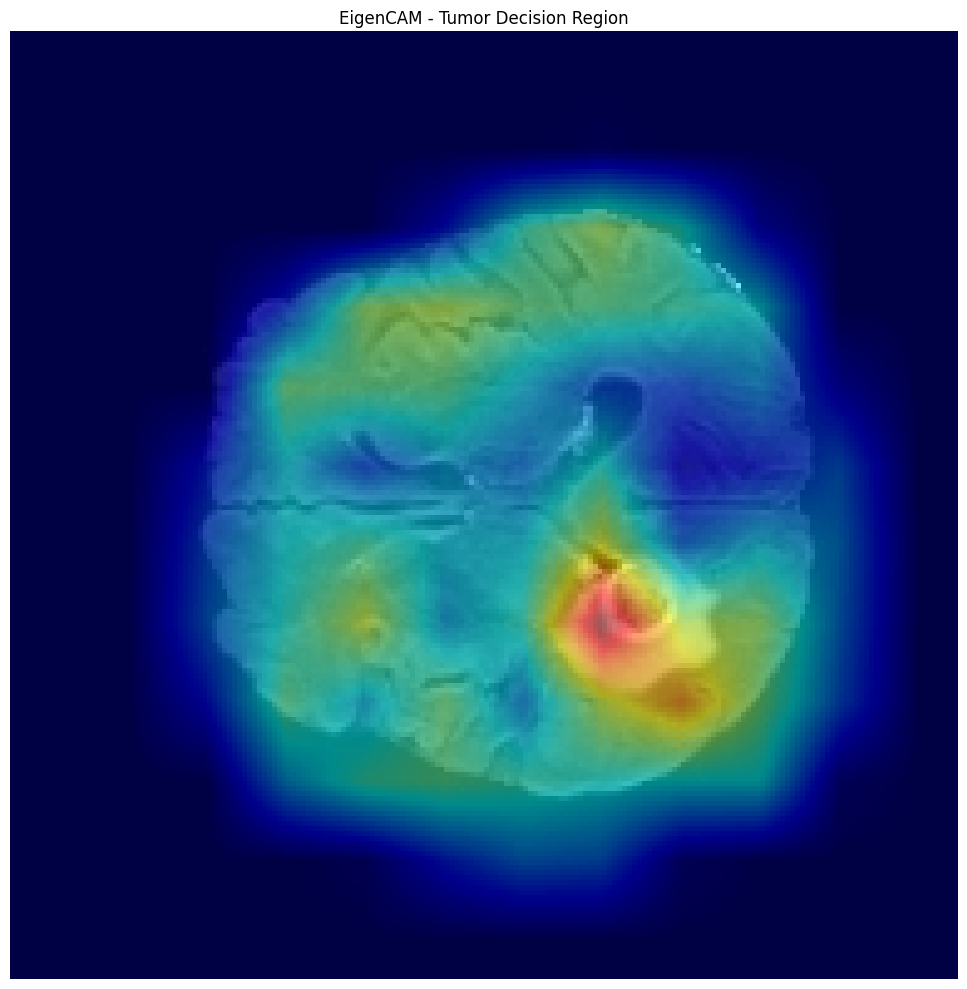

In [ ]:
from pytorch_grad_cam import EigenCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import cv2

pytorch_model = model.model
pytorch_model.eval()

class YOLOv8Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        return out

wrapped_model = YOLOv8Wrapper(pytorch_model)
target_layer = pytorch_model.model[18]

sample_name = "tumor_73"
sample_image_path = os.path.join(BASE_DIR, "images", "val", f"{sample_name}.jpg")

original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img_resized = cv2.resize(original_img, (192, 192))
original_float = original_img_resized.astype("float32") / 255.0
img_tensor = torch.from_numpy(original_float).permute(2, 0, 1).unsqueeze(0).float().to(next(pytorch_model.parameters()).device)

class TumorClassTarget:
    def __call__(self, model_output):
        raw_output = model_output[0] if isinstance(model_output, (tuple, list)) else model_output
        if raw_output.ndim == 3 and raw_output.shape[1] == 5:
            return raw_output[:, 4, :].sum()
        return raw_output.flatten().sum()

target = TumorClassTarget()
cam = EigenCAM(model=wrapped_model, target_layers=[target_layer])
grayscale_cam = cam(input_tensor=img_tensor, targets=[target])[0]

visualization = show_cam_on_image(original_float, grayscale_cam, use_rgb=True)
plt.figure(figsize=(10, 10))
plt.imshow(visualization)
plt.axis("off")
plt.title("EigenCAM - Tumor Decision Region")
plt.tight_layout()
plt.show()

In [ ]:
class TumorClassTarget:
    # Print output shape to understand YOLO's raw output structure
    def __call__(self, model_output):
        if isinstance(model_output, (tuple, list)):
            raw_output = model_output[0]
        else:
            raw_output = model_output
        
        print(f"DEBUG - raw_output shape: {raw_output.shape}")
        print(f"DEBUG - raw_output ndim: {raw_output.ndim}")
        
        # if its 4D: [batch, channels, height, width] - need to reshape
        if raw_output.ndim == 4:
            print("Output is 4D - treating as [batch, channels, H, W]")
            return raw_output.max()
        
        # if its 3D: [batch, num_anchors, 85]
        elif raw_output.ndim == 3:
            print(f"Output is 3D [batch={raw_output.shape[0]}, anchors={raw_output.shape[1]}, features={raw_output.shape[2]}]")
            objectness = raw_output[:, :, 4]
            class_score = raw_output[:, :, 5]
            confidence = objectness * class_score
            return confidence.max()
        
        print(f"Unexpected shape - returning max: {raw_output.shape}")
        return raw_output.max()

In [30]:
target = TumorClassTarget()
output = wrapped_model(img_tensor)

print("wrapped output type:", type(output))
if isinstance(output, (tuple, list)):
    print("wrapped output length:", len(output))
print("target score:", target(output))

wrapped output type: <class 'torch.Tensor'>
DEBUG - raw_output shape: torch.Size([1, 5, 756])
DEBUG - raw_output ndim: 3
Output is 3D [batch=1, anchors=5, features=756]
target score: tensor(4264.2798)


# Score CAM

100%|██████████| 8/8 [00:00<00:00, 18.22it/s]


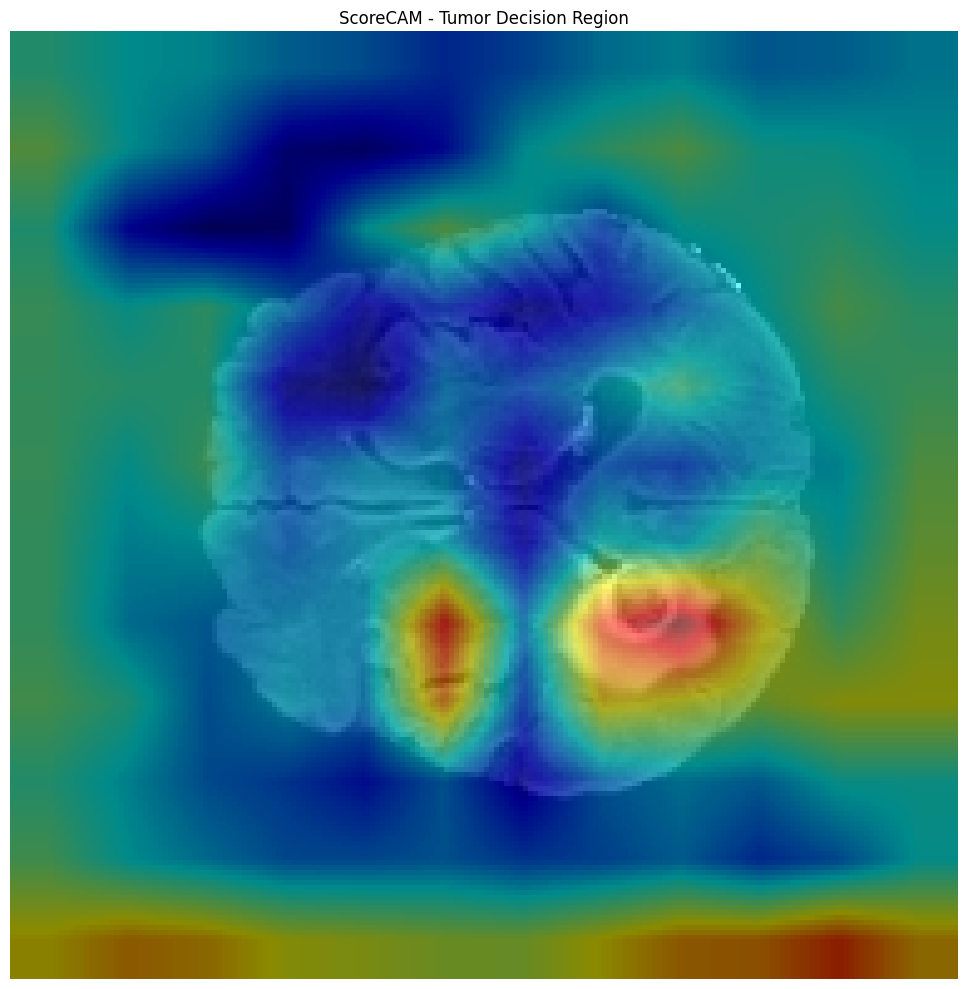

In [51]:
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch
import cv2

pytorch_model = model.model
pytorch_model.eval()

class YOLOv8Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        return out

wrapped_model = YOLOv8Wrapper(pytorch_model)
target_layer = pytorch_model.model[18]

sample_name = "tumor_73"
sample_image_path = os.path.join(BASE_DIR, "images", "val", f"{sample_name}.jpg")
original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img_resized = cv2.resize(original_img, (192, 192))
original_img_normalized = original_img_resized.astype("float32") / 255.0
img_tensor = torch.from_numpy(original_img_normalized).permute(2, 0, 1).unsqueeze(0).float().to(next(pytorch_model.parameters()).device)

class TumorClassTarget:
    def __call__(self, model_output):
        raw_output = model_output[0] if isinstance(model_output, (tuple, list)) else model_output
        if raw_output.ndim == 3 and raw_output.shape[1] == 5:
            return raw_output[:, 4, :].max()
        return raw_output.flatten().max()

target = TumorClassTarget()
cam = ScoreCAM(model=wrapped_model, target_layers=[target_layer], reshape_transform=None)
grayscale_cam = cam(input_tensor=img_tensor, targets=[target])[0]
visualization = show_cam_on_image(original_img_normalized, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 10))
plt.imshow(visualization)
plt.axis("off")
plt.title("ScoreCAM - Tumor Decision Region")
plt.tight_layout()
plt.show()

# Grad CAM plus plus

GradCAM++ target layer: C2f(
  (cv1): Conv(
    (conv): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Conv(
    (conv): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (m): ModuleList(
    (0): Bottleneck(
      (cv1): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (act): SiLU(inplace=True)
      )
    )
  )
)


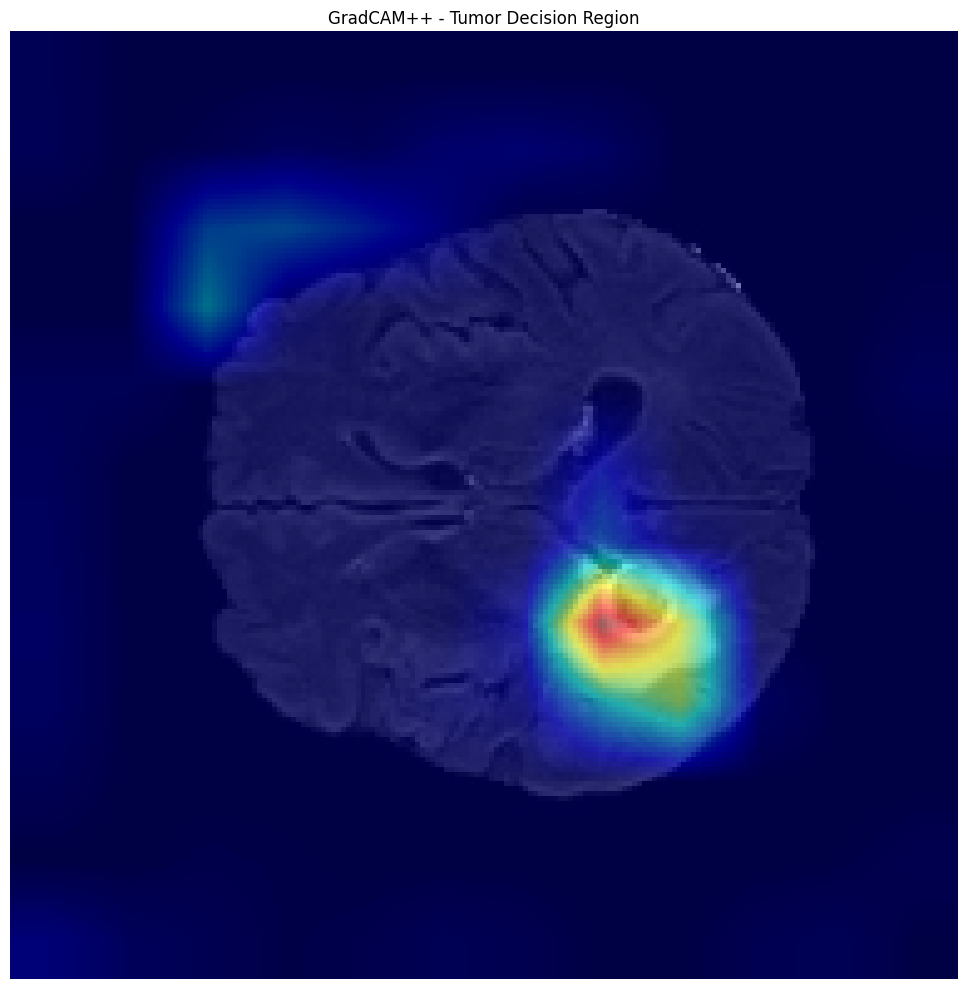

In [ ]:
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch

pytorch_model = model.model
pytorch_model.eval()

class YOLOv8Wrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        out = self.model(x)
        if isinstance(out, (tuple, list)):
            out = out[0]
        return out

wrapped_model = YOLOv8Wrapper(pytorch_model)

target_layer = pytorch_model.model[18]
print("GradCAM++ target layer:", target_layer)

sample_name = "tumor_73"
label_path = os.path.join(BASE_DIR, "labels", "val", f"{sample_name}.txt")
if os.path.exists(label_path):
    sample_image_path = os.path.join(BASE_DIR, "images", "val", f"{sample_name}.jpg")
else:
    val_labels = [f for f in os.listdir(os.path.join(BASE_DIR, "labels", "val")) if f.endswith('.txt')]
    if len(val_labels) == 0:
        raise FileNotFoundError("No validation labels found in brain_tumor_dataset/labels/val")
    sample_name = os.path.splitext(val_labels[0])[0]
    sample_image_path = os.path.join(BASE_DIR, "images", "val", f"{sample_name}.jpg")

original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
original_img_resized = cv2.resize(original_img, (192, 192))
original_img_normalized = original_img_resized.astype("float32") / 255.0
img_tensor = torch.from_numpy(original_img_normalized).permute(2, 0, 1).unsqueeze(0).float()

device = next(pytorch_model.parameters()).device
img_tensor = img_tensor.to(device)

class TumorClassTarget:
    def __call__(self, model_output):
        raw_output = model_output[0] if isinstance(model_output, (tuple, list)) else model_output
        if raw_output.ndim == 3 and raw_output.shape[1] == 5:
            return raw_output[:, 4, :].sum()
        return raw_output.flatten().sum()

class GradCAMPlusPlusCustom:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

    def _save_activation_and_grad(self, module, input, output):
        self.activations = output
        def save_grad(grad):
            self.gradients = grad
        output.register_hook(save_grad)

    def __call__(self, input_tensor, target):
        handle = self.target_layer.register_forward_hook(self._save_activation_and_grad)
        input_tensor = input_tensor.clone().detach().requires_grad_(True)
        output = self.model(input_tensor)
        loss = target(output)
        self.model.zero_grad()
        loss.backward(retain_graph=True)
        handle.remove()

        activations = self.activations
        gradients = self.gradients
        if activations is None or gradients is None:
            raise RuntimeError("GradCAM++ could not capture activations or gradients.")

        grads_power_2 = gradients.pow(2)
        grads_power_3 = gradients.pow(3)
        sum_activations = activations.sum(dim=(2, 3), keepdim=True)
        alpha_denom = 2 * grads_power_2 + sum_activations * grads_power_3 + 1e-8
        alpha = grads_power_2 / alpha_denom
        weights = torch.relu(gradients) * alpha
        weights = weights.sum(dim=(2, 3), keepdim=True)

        cam = (weights * activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze(0).squeeze(0).detach().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

target = TumorClassTarget()
cam = GradCAMPlusPlusCustom(wrapped_model, target_layer)

grayscale_cam = cam(input_tensor=img_tensor, target=target)
visualization = show_cam_on_image(original_img_normalized, grayscale_cam, use_rgb=True)

plt.figure(figsize=(10, 10))
plt.imshow(visualization)
plt.axis("off")
plt.title("GradCAM++ - Tumor Decision Region")
plt.tight_layout()
plt.show()

# SHAP

In [34]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [35]:
import shap
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [36]:
def yolo_predict(images):

    outputs = []

    for img in images:

        img = img.astype(np.uint8)

        results = model.predict(
            img,
            verbose=False
        )[0]

        if len(results.boxes) > 0:

            score = float(
                results.boxes.conf.max().cpu().numpy()
            )

        else:
            score = 0.0

        outputs.append(score)

    return np.array(outputs)

In [37]:
image_path = "brain_tumor_dataset/images/val/tumor_73.jpg"
image = cv2.imread(image_path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

image = cv2.resize(
    image,
    (224,224)
)

In [38]:
masker = shap.maskers.Image(
    "blur(32,32)",
    image.shape
)

explainer = shap.Explainer(
    yolo_predict,
    masker
)

In [39]:
shap_values = explainer(
    image[np.newaxis,:,:,:],
    max_evals=500
)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:11, 11.38s/it]               


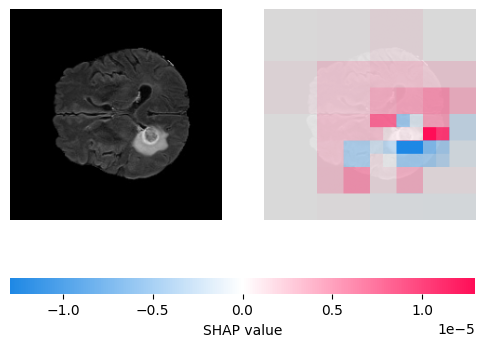

In [40]:
shap.image_plot(
    shap_values
)